<h1 align="center"><b>Homework Assignment 4 (100 points total)</b></h1>
<h3 align="center"><b>Assigned at the start of Module 8</b></h3>
<h3 align="center"><b>Due at the end of Module 11</b></h3><br>

# Q1 — Training Models with Gradient Descent and Its Variants  

## 30 points total

In this problem, you will get hands-on experience with gradient-based optimization algorithms. You will first apply them to a simple convex model (logistic regression) and then explore their behavior on a small non-convex model (neural network). The goal is to understand how and why these algorithms behave differently in practice.

---

## [10 points] Part A – Learning to Separate Two Classes

In this part, you will implement gradient descent from scratch to understand how it learns and converges.

### Dataset  

```python
import numpy as np

# Simple linearly separable data
X = np.array([[0,1],[1,2],[2,1],[3,2],[3,4],[4,3],[5,4],[6,5]])
y = np.array([0,0,0,0,1,1,1,1])  # 0 = Class A, 1 = Class B

```

### Model
- Implement logistic regression using batch gradient descent (use all data to compute the gradient each step).
- Start all parameters $(w, b)$ = 0, learning rate = 0.1.
- Run 1000 updates and plot the loss curve (loss vs. iterations).

### Visualization and Interpretation
- Draw a scatter plot showing the decision boundary learned by your model.
- Provide interpretation of your plot(s), such as
    - Does the loss steadily decrease? 
    - How does learning rate affect stability?


## [10 points] Part B – Comparing how fast models learn  

In this part, you will use gradient descent as a baseline and compare it to other optimizers.

### Dataset and Model

- Use the same dataset and loss function as in Part A.
- Train the same model using three optimizers
    - Batch Gradient Descent (GD)
    - Stochastic Gradient Descent (SGD)
    - Adam 
- Run each for 20 epochs.

### Visualization and Interpreation
- Plot all three loss curves on one graph.
- Provide interpretation of your plot(s), such as convergence speed, stability, etc.


## [10 points] Part C - Non-Convex Terrain

In this part, you will explore how optimization behaves in non-convex landscapes, where initialization matters.

### Model

- Build and train a tiny neural network, with its architecture as \
Input -> Hidden Layer (2 neurons, ReLU) -> Output (Sigmoid)
- Train the network using Adam on the same dataset as in Part A.
- Run the training three times with different random weight initializations.


### Visualization and Interpretation
- Plot the loss curve for each run
- Discuss your results and plots, for example, 
    - Do all runs end at the same loss value?
    - Why might some runs get "stuck" higher?
    - What does this show about challenges of non-convex optimization?


## Part A Solution

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simple linearly separable data
X = np.array([
    [0,1],
    [1,2],
    [2,1],
    [3,2],
    [3,4],
    [4,3],
    [5,4],
    [6,5]
], dtype=float)

y = np.array([0,0,0,0,1,1,1,1], dtype=float)

### Helper Functions
Logistic regression model:

$$\hat{y} = \sigma(Xw + b)$$

Where:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Binary cross-entropy loss:
$$L = -\frac{1}{n}\sum_{i=1}^n \left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(
        y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
    )


def predict_proba_logreg(X, w, b):
    return sigmoid(X @ w + b)


def compute_loss_logreg(X, y, w, b):
    y_pred = predict_proba_logreg(X, w, b)
    return binary_cross_entropy(y, y_pred)

### Batch Gradient Descent Implementation
For logistic regression with binary cross-entropy, the gradients are:
$$\frac{\partial L}{\partial w} = \frac{1}{n}X^T(\hat{y}-y)$$
$$\frac{\partial L}{\partial b} = \frac{1}{n}\sum_{i=1}^n(\hat{y}_i-y_i)$$

In [3]:
def train_logreg_gd(X, y, lr=0.1, n_updates=1000):
    n_samples, n_features = X.shape

    # Initialize parameters to zero
    w = np.zeros(n_features)
    b = 0.0

    losses = []

    for step in range(n_updates):
        # Forward pass
        y_pred = predict_proba_logreg(X, w, b)
        loss = binary_cross_entropy(y, y_pred)
        losses.append(loss)

        # Gradients
        error = y_pred - y
        dw = (X.T @ error) / n_samples
        db = np.mean(error)

        # Parameter update
        w -= lr * dw
        b -= lr * db

    return w, b, losses

### Train for 1000 Updates

In [4]:
w_gd, b_gd, losses_gd = train_logreg_gd(X, y, lr=0.1, n_updates=1000)

print("Learned weights:", w_gd)
print("Learned bias:", b_gd)
print("Final loss:", losses_gd[-1])

Learned weights: [0.53872605 1.6591005 ]
Learned bias: -5.733851531773794
Final loss: 0.11351938987294843


### Plot Loss Curve

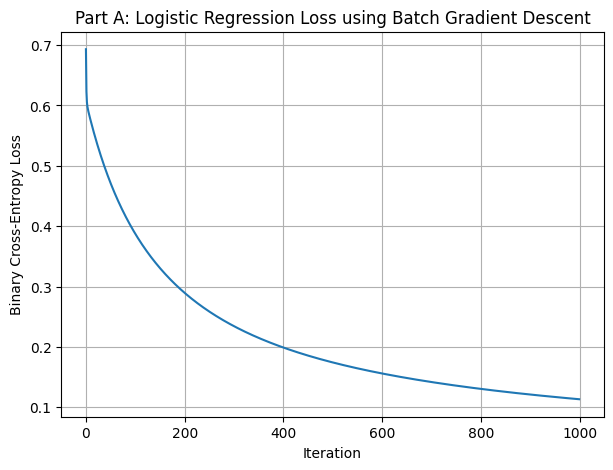

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(losses_gd)
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Part A: Logistic Regression Loss using Batch Gradient Descent")
plt.grid(True)
plt.show()

### Plot Decision Boundary
The decision boundary occurs when:
$$w_1x_1 + w_2x_2 + b = 0$$

Solving for $x_2$:
$$x_2 = -\frac{w_1x_1 + b}{w_2}$$

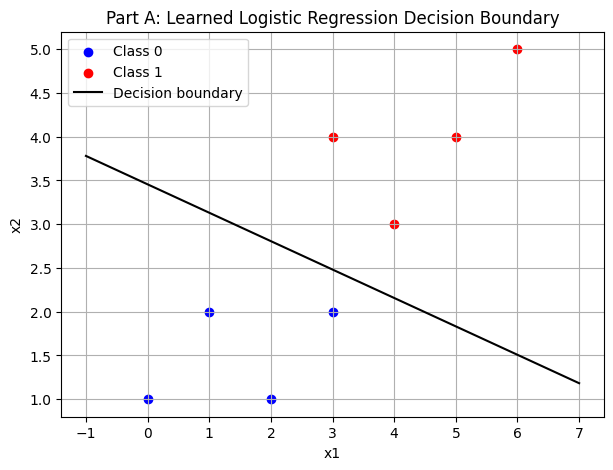

In [6]:
def plot_decision_boundary_logreg(X, y, w, b):
    plt.figure(figsize=(7, 5))

    # Scatter plot
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color="blue", label="Class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color="red", label="Class 1")

    # Decision boundary
    x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)

    if abs(w[1]) > 1e-12:
        y_vals = -(w[0] * x_vals + b) / w[1]
        plt.plot(x_vals, y_vals, color="black", label="Decision boundary")
    else:
        x_boundary = -b / w[0]
        plt.axvline(x_boundary, color="black", label="Decision boundary")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Part A: Learned Logistic Regression Decision Boundary")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_decision_boundary_logreg(X, y, w_gd, b_gd)

### Interpretation
The loss should steadily decrease because logistic regression with binary cross-entropy is a convex optimization problem. Since the dataset is linearly separable, the model can find a linear decision boundary that separates the two classes well.

With a learning rate of 0.1, training is usually stable on this small dataset. If the learning rate is much smaller, for example 0.001, the loss decreases more slowly. If the learning rate is too large, for example 5.0 or 10.0, updates may overshoot the minimum direction and the loss can oscillate or become unstable.

Because this dataset is linearly separable, logistic regression can keep increasing the magnitude of the weights to make predictions more confident. Therefore, the loss may continue to decrease slowly even after the boundary already separates the data.



## Part B Solution

We train the same logistic regression model using:

* Batch Gradient Descent
* Stochastic Gradient Descent
* Adam

Each optimizer runs for 20 epochs. An epoch means one pass over the full dataset. For batch gradient descent, one epoch gives one update. For SGD, one epoch gives one update per training example.

### Gradient Function

In [7]:
def logreg_gradients(X_batch, y_batch, w, b):
    n = len(y_batch)
    y_pred = predict_proba_logreg(X_batch, w, b)
    error = y_pred - y_batch

    dw = (X_batch.T @ error) / n
    db = np.mean(error)

    loss = binary_cross_entropy(y_batch, y_pred)
    return dw, db, loss

### Batch Gradient Descent

In [8]:
def train_logreg_gd_epochs(X, y, lr=0.1, epochs=20):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    losses = []

    for epoch in range(epochs):
        dw, db, _ = logreg_gradients(X, y, w, b)

        w -= lr * dw
        b -= lr * db

        epoch_loss = compute_loss_logreg(X, y, w, b)
        losses.append(epoch_loss)

    return w, b, losses

### Stochastic Gradient Descent

In [9]:
def train_logreg_sgd(X, y, lr=0.1, epochs=20, seed=0):
    rng = np.random.default_rng(seed)
    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    b = 0.0

    losses = []

    for epoch in range(epochs):
        indices = rng.permutation(n_samples)

        for idx in indices:
            Xi = X[idx:idx+1]
            yi = y[idx:idx+1]

            dw, db, _ = logreg_gradients(Xi, yi, w, b)

            w -= lr * dw
            b -= lr * db

        epoch_loss = compute_loss_logreg(X, y, w, b)
        losses.append(epoch_loss)

    return w, b, losses

### Adam

In [10]:
def train_logreg_adam(X, y, lr=0.1, epochs=20, beta1=0.9, beta2=0.999, eps=1e-8):
    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    b = 0.0

    mw = np.zeros_like(w)
    vw = np.zeros_like(w)
    mb = 0.0
    vb = 0.0

    losses = []
    t = 0

    for epoch in range(epochs):
        # Full-batch Adam update
        t += 1

        dw, db, _ = logreg_gradients(X, y, w, b)

        # First moment estimates
        mw = beta1 * mw + (1 - beta1) * dw
        mb = beta1 * mb + (1 - beta1) * db

        # Second moment estimates
        vw = beta2 * vw + (1 - beta2) * (dw ** 2)
        vb = beta2 * vb + (1 - beta2) * (db ** 2)

        # Bias correction
        mw_hat = mw / (1 - beta1 ** t)
        mb_hat = mb / (1 - beta1 ** t)
        vw_hat = vw / (1 - beta2 ** t)
        vb_hat = vb / (1 - beta2 ** t)

        # Update
        w -= lr * mw_hat / (np.sqrt(vw_hat) + eps)
        b -= lr * mb_hat / (np.sqrt(vb_hat) + eps)

        epoch_loss = compute_loss_logreg(X, y, w, b)
        losses.append(epoch_loss)

    return w, b, losses

### Train All Three Optimizers

In [11]:
epochs = 20

w_gd_b, b_gd_b, losses_gd_b = train_logreg_gd_epochs(X, y, lr=0.1, epochs=epochs)
w_sgd_b, b_sgd_b, losses_sgd_b = train_logreg_sgd(X, y, lr=0.1, epochs=epochs, seed=1)
w_adam_b, b_adam_b, losses_adam_b = train_logreg_adam(X, y, lr=0.1, epochs=epochs)

print("Final GD loss:", losses_gd_b[-1])
print("Final SGD loss:", losses_sgd_b[-1])
print("Final Adam loss:", losses_adam_b[-1])

Final GD loss: 0.5438099750821701
Final SGD loss: 0.3352590759881562
Final Adam loss: 0.3602816814897681


### Plot comparison

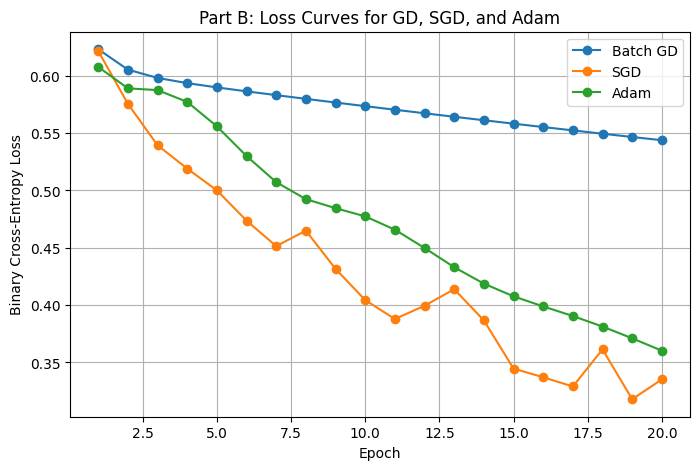

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), losses_gd_b, marker="o", label="Batch GD")
plt.plot(range(1, epochs + 1), losses_sgd_b, marker="o", label="SGD")
plt.plot(range(1, epochs + 1), losses_adam_b, marker="o", label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Part B: Loss Curves for GD, SGD, and Adam")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation for Part B
Batch gradient descent uses the entire dataset for each update, so its loss curve is usually smooth and stable. However, in 20 epochs it only performs 20 parameter updates, so it may learn relatively slowly.

SGD updates after every single training example. On this dataset, each epoch contains 8 SGD updates, so over 20 epochs SGD makes 160 updates. This often allows it to reduce the loss faster than batch GD in terms of epochs. However, its loss curve may be noisier because each update uses only one data point and therefore the gradient direction is a noisy estimate of the full gradient.

Adam typically converges faster than plain GD because it adapts the step size separately for each parameter using estimates of the first and second moments of the gradient. Its curve is often stable and fast-decreasing. On a very small dataset like this one, SGD may sometimes appear competitive because it performs many updates per epoch, but Adam is generally more robust to learning-rate choices.

## Part C — Non-Convex Terrain with a Tiny Neural Network

Now we train a neural network that flows like this:
$$\text{Input} \rightarrow \text{Hidden Layer with 2 ReLU neurons} \rightarrow \text{Sigmoid Output}$$

This model is non-convex because of the hidden layer and ReLU non-linearity. Different random initializations can lead to different optimization paths.

### Neural network helper functions

In [13]:
def relu(z):
    return np.maximum(0, z)


def relu_derivative(z):
    return (z > 0).astype(float)

The model is:
$$Z_1 = XW_1 + b_1$$
$$A_1 = \text{ReLU}(Z_1)$$
$$Z_2 = A_1W_2 + b_2$$
$$\hat{y} = \sigma(Z_2)$$

In [14]:
def nn_forward(X, params):
    W1 = params["W1"]
    b1 = params["b1"]
    W2 = params["W2"]
    b2 = params["b2"]

    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    y_pred = sigmoid(Z2).reshape(-1)

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "y_pred": y_pred
    }

    return y_pred, cache

### Initialize Parameters

In [15]:
def initialize_nn(seed=None):
    rng = np.random.default_rng(seed)

    params = {
        # Input dimension 2, hidden dimension 2
        "W1": rng.normal(0, 0.5, size=(2, 2)),
        "b1": np.zeros(2),

        # Hidden dimension 2, output dimension 1
        "W2": rng.normal(0, 0.5, size=(2, 1)),
        "b2": np.zeros(1)
    }

    return params

### Backpropagation

For binary cross-entropy with sigmoid output:
$$dZ_2 = \hat{y} - y$$

In [16]:
def nn_gradients(X, y, params):
    n = X.shape[0]

    y_pred, cache = nn_forward(X, params)

    Z1 = cache["Z1"]
    A1 = cache["A1"]

    # Make shapes explicit
    dZ2 = (y_pred - y).reshape(-1, 1)

    dW2 = (A1.T @ dZ2) / n
    db2 = np.mean(dZ2, axis=0)

    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = (X.T @ dZ1) / n
    db1 = np.mean(dZ1, axis=0)

    grads = {
        "W1": dW1,
        "b1": db1,
        "W2": dW2,
        "b2": db2
    }

    loss = binary_cross_entropy(y, y_pred)

    return grads, loss

### Adam for Neural Network

In [17]:
def train_nn_adam(X, y, seed=None, lr=0.05, epochs=1000,
                  beta1=0.9, beta2=0.999, eps=1e-8):
    params = initialize_nn(seed)

    m = {key: np.zeros_like(value) for key, value in params.items()}
    v = {key: np.zeros_like(value) for key, value in params.items()}

    losses = []

    for t in range(1, epochs + 1):
        grads, loss = nn_gradients(X, y, params)
        losses.append(loss)

        for key in params:
            m[key] = beta1 * m[key] + (1 - beta1) * grads[key]
            v[key] = beta2 * v[key] + (1 - beta2) * (grads[key] ** 2)

            m_hat = m[key] / (1 - beta1 ** t)
            v_hat = v[key] / (1 - beta2 ** t)

            params[key] -= lr * m_hat / (np.sqrt(v_hat) + eps)

    return params, losses

### Run 3 Different Initializations

In [18]:
seeds = [0, 1, 2]
nn_results = {}

for seed in seeds:
    params, losses = train_nn_adam(X, y, seed=seed, lr=0.05, epochs=1000)
    nn_results[seed] = {
        "params": params,
        "losses": losses
    }
    print(f"Seed {seed}: final loss = {losses[-1]:.6f}")

Seed 0: final loss = 0.000906
Seed 1: final loss = 0.000810
Seed 2: final loss = 0.693147


### Plot Loss Curves

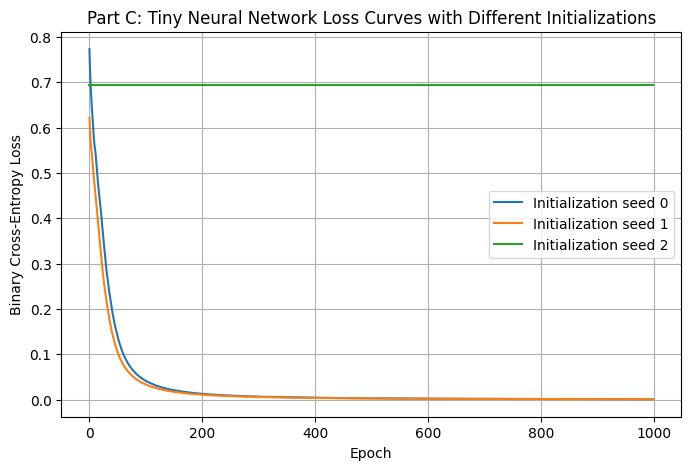

In [19]:
plt.figure(figsize=(8, 5))

for seed in seeds:
    plt.plot(nn_results[seed]["losses"], label=f"Initialization seed {seed}")

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Part C: Tiny Neural Network Loss Curves with Different Initializations")
plt.legend()
plt.grid(True)
plt.show()

### Plot Neural Network Decision Regions

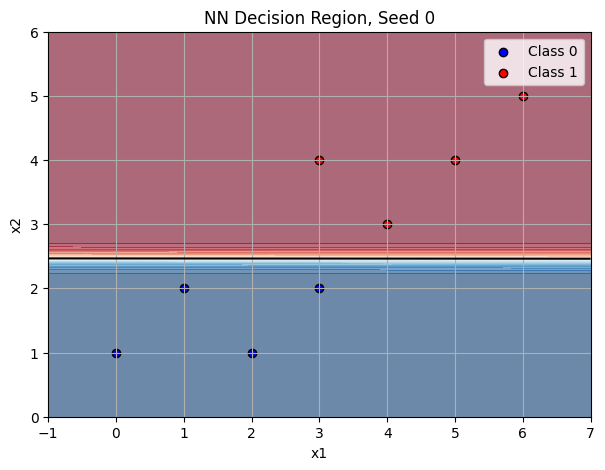

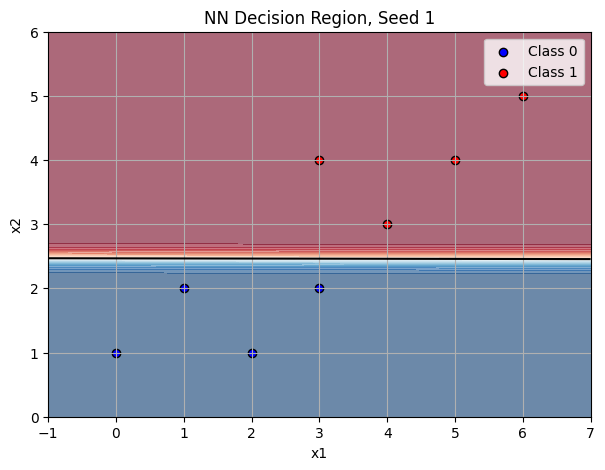

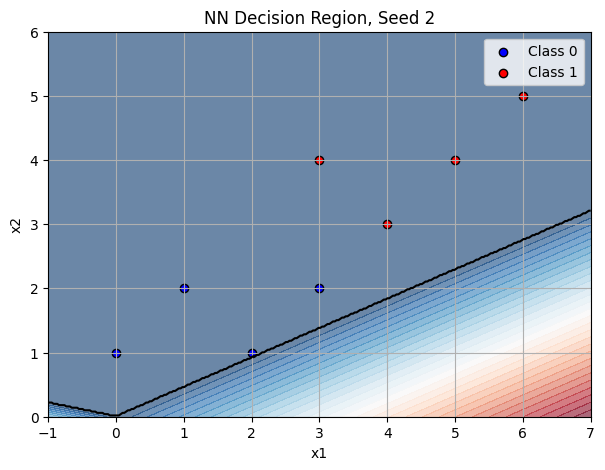

In [20]:
def predict_nn(X, params):
    y_pred, _ = nn_forward(X, params)
    return (y_pred >= 0.5).astype(int)


def plot_nn_decision_region(X, y, params, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs, _ = nn_forward(grid, params)
    Z = probs.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, levels=30, cmap="RdBu_r", alpha=0.6)
    plt.contour(xx, yy, Z, levels=[0.5], colors="black")

    plt.scatter(X[y == 0, 0], X[y == 0, 1], color="blue", edgecolor="k", label="Class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color="red", edgecolor="k", label="Class 1")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


for seed in seeds:
    plot_nn_decision_region(
        X, y,
        nn_results[seed]["params"],
        title=f"NN Decision Region, Seed {seed}"
    )

### Interpretation for Part C

The neural network optimization problem is non-convex because the model contains a hidden layer with ReLU activations. Unlike logistic regression, the loss surface can contain flat regions, saddle points, and poor local minima.

Different random initializations may lead to different training trajectories. In many runs, Adam will find a low-loss solution because the dataset is simple and small. However, the three runs may not all end at exactly the same final loss. Some runs may converge faster, some slower, and occasionally one may get stuck at a higher loss.

One reason a run might get stuck is the ReLU activation. If a hidden neuron receives inputs that make its pre-activation negative for all training examples, then its output is always zero and its gradient is also zero. This is sometimes called a dead ReLU. In that case, part of the network stops learning.

This demonstrates an important challenge of non-convex optimization - the final solution can depend on initialization. Even when using the same optimizer, same learning rate, and same data, different starting weights can produce different loss curves and different learned decision boundaries.

# Q2 — Designing and Solving Your Own Reinforcement Learning Environment

## 30 points total

### [15 points] Part A – Design and Implement a Custom RL Environment

__Goal:__ Define and implement a small custom environment that can be solved using **Q-Learning**

1. Use the [Gymnasium API structure](https://gymnasium.farama.org/introduction/create_custom_env/):

```python
# starter code if you need it. Use documentation. Focus on design rather than syntax.
import gymnasium as gym
from gymnasium import spaces

class CustomEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.observation_space = spaces.Discrete(...)
        self.action_space = spaces.Discrete(...)
        # define internal dynamics

    def reset(self, seed=None, options=None):
        # return initial state, info
        return state, {}

    def step(self, action):
        # define transitions, rewards, terminal condition
        return next_state, reward, terminated, truncated, {}
```
2. Choose one of these types of problems:

   - Grid-based navigation (agent finds goal, avoids obstacles)
   - Resource management (agent balances energy/reward trade-offs)
   - Sequential decision process (agent makes timed choices with delayed reward)

3. Your environment must have:

   - At least 8–12 discrete states
   - At least 2–4 actions
   - Clearly defined stochastic or deterministic transitions
   - A nontrivial reward structure (some decisions should require exploration)

4. Include a diagram of your environment (state transitions, rewards, or layout).
---

### [15 points] Part B – Apply Q-Learning and Analyze Results

- Implement Q-Learning
- Train for 1000+ episodes
- Plot:
  - Moving average of total episode reward
  - Final Q-table
  - Learning policy visualization

Analysis:
1. What did the agent learn?
   - Describe the final policy and what behaviors emerged
2. How does your reward design affect convergence?
   - Did the agent learn what you expected?
3. If you adjusted $\gamma$ or $\epsilon$, how did learning change?
4. What are the failure modes?
   - What would make your environment "harder" or "easier"?



### Part A Solution

### Environment: Treasure Grid World
We design a small grid-based navigation environment. The agent starts in the top-left corner and must reach the goal in the bottom-right corner. There are obstacles, a trap, and a small treasure cell. The agent must learn to avoid bad states and reach the goal efficiently.

### Grid Layout
We use a 3 x 4 grid, giving 12 possible discrete states.

```
+-----+-----+-----+-----+
|  S  |     |  T  |     |
+-----+-----+-----+-----+
|     |  X  |     |     |
+-----+-----+-----+-----+
|  B  |     |     |  G  |
+-----+-----+-----+-----+
```

Where:
* S = start state
* G = goal
* X = obstacle/wall
* T = treasure
* B = bad/trap cell

#### Coordinates
```
+---------+---------+---------+---------+
| (0,0) S | (0,1)   | (0,2) T | (0,3)   |
+---------+---------+---------+---------+
| (1,0)   | (1,1) X | (1,2)   | (1,3)   |
+---------+---------+---------+---------+
| (2,0) B | (2,1)   | (2,2)   | (2,3) G |
+---------+---------+---------+---------+
```

#### State Numbering
```
+----+----+----+----+
|  0 |  1 |  2 |  3 |
+----+----+----+----+
|  4 |  5 |  6 |  7 |
+----+----+----+----+
|  8 |  9 | 10 | 11 |
+----+----+----+----+
```

#### State meanings
| State | Coordinate | Meaning       |
|------:|:----------:|---------------|
|     0 |   (0,0)    | Start         |
|     1 |   (0,1)    | Empty         |
|     2 |   (0,2)    | Treasure      |
|     3 |   (0,3)    | Empty         |
|     4 |   (1,0)    | Empty         |
|     5 |   (1,1)    | Wall/obstacle |
|     6 |   (1,2)    | Empty         |
|     7 |   (1,3)    | Empty         |
|     8 |   (2,0)    | Bad/trap      |
|     9 |   (2,1)    | Empty         |
|    10 |   (2,2)    | Empty         |
|    11 |   (2,3)    | Goal          |

The obstacle in state 5 cannot be entered. If the agent tries to move into it, it stays in the current state.

### Actions
There are 4 discrete actions:

| Action | Meaning |
|-------:|---------|
|      0 | Up      |
|      1 | Right   |
|      2 | Down    |
|      3 | Left    |

### Rewards
The reward structure is:

| Event                                    | Reward |
|------------------------------------------|-------:|
| Each normal step                         |     -1 |
| Trying to move into wall or outside grid |     -5 |
| Enter treasure cell T                    |     +5 |
| Enter bad cell B                         |    -10 |
| Enter goal cell G                        |    +20 |

The episode terminates when the agent reaches the goal. There is also a max step limit to avoid infinite episodes. This reward structure is nontrivial because the agent must balance:

* Reaching the goal quickly.
* Avoiding the trap.
* Avoiding wasting moves against walls.
* (Optional) Collecting treasure if it is worth the detour.


### Custom Gymnasium Environment

In [21]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import seaborn as sns

class TreasureGridEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, max_steps=50):
        super().__init__()

        self.n_rows = 3
        self.n_cols = 4
        self.n_states = self.n_rows * self.n_cols
        self.n_actions = 4

        self.observation_space = spaces.Discrete(self.n_states)
        self.action_space = spaces.Discrete(self.n_actions)

        self.start_pos = (0, 0)
        self.goal_pos = (2, 3)
        self.wall_pos = (1, 1)
        self.treasure_pos = (0, 2)
        self.bad_pos = (2, 0)

        self.max_steps = max_steps
        self.current_pos = self.start_pos
        self.steps = 0

    def pos_to_state(self, pos):
        row, col = pos
        return row * self.n_cols + col

    def state_to_pos(self, state):
        row = state // self.n_cols
        col = state % self.n_cols
        return (row, col)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_pos = self.start_pos
        self.steps = 0
        return self.pos_to_state(self.current_pos), {}

    def step(self, action):
        self.steps += 1

        row, col = self.current_pos
        new_row, new_col = row, col

        # Action mapping
        # 0 = up, 1 = right, 2 = down, 3 = left
        if action == 0:
            new_row -= 1
        elif action == 1:
            new_col += 1
        elif action == 2:
            new_row += 1
        elif action == 3:
            new_col -= 1

        candidate_pos = (new_row, new_col)

        terminated = False
        truncated = False

        # Default step reward
        reward = -1

        # Check boundaries
        out_of_bounds = (
            new_row < 0 or new_row >= self.n_rows or
            new_col < 0 or new_col >= self.n_cols
        )

        if out_of_bounds:
            # Stay in place if hitting boundary
            next_pos = self.current_pos
            reward = -5

        elif candidate_pos == self.wall_pos:
            # Stay in place if hitting wall
            next_pos = self.current_pos
            reward = -5

        else:
            next_pos = candidate_pos

            if next_pos == self.treasure_pos:
                reward = 5

            elif next_pos == self.bad_pos:
                reward = -10

            elif next_pos == self.goal_pos:
                reward = 20
                terminated = True

        self.current_pos = next_pos

        if self.steps >= self.max_steps:
            truncated = True

        next_state = self.pos_to_state(self.current_pos)

        return next_state, reward, terminated, truncated, {}

    def render(self):
        grid = np.full((self.n_rows, self.n_cols), ".", dtype=object)

        grid[self.start_pos] = "S"
        grid[self.goal_pos] = "G"
        grid[self.wall_pos] = "X"
        grid[self.treasure_pos] = "T"
        grid[self.bad_pos] = "B"

        agent_row, agent_col = self.current_pos
        grid[agent_row, agent_col] = "A"

        print(grid)

### Test the Environment

In [22]:
env = TreasureGridEnv()
state, info = env.reset()

print("Initial state:", state)
env.render()

next_state, reward, terminated, truncated, info = env.step(1)  # move right
print("Next state:", next_state)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
env.render()

Initial state: 0
[['A' '.' 'T' '.']
 ['.' 'X' '.' '.']
 ['B' '.' '.' 'G']]
Next state: 1
Reward: -1
Terminated: False
Truncated: False
[['S' 'A' 'T' '.']
 ['.' 'X' '.' '.']
 ['B' '.' '.' 'G']]


## Part B Solution

### Q-Learning Algorithm
Q-learning update rule:
$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s', a') - Q(s,a)\right]$$

Where:
* $\alpha$ is the learning rate.
* $\gamma$ is the discount factor.
* $r$ is the reward.
* $s$ is the current state.
* $a$ is the selected action.
* $s^\prime$ is the next state.

### Training Function
We use epsilon-greedy exploration. With probability $\epsilon$, the agent chooses a random action. With probability $1-\epsilon$, the agent chooses the action with the highest Q-value.

In [23]:
def train_q_learning(
    env,
    episodes=3000,
    alpha=0.1,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))

    episode_rewards = []
    epsilons = []

    epsilon = epsilon_start

    for episode in range(episodes):
        state, info = env.reset()
        total_reward = 0

        terminated = False
        truncated = False

        while not terminated and not truncated:
            # Epsilon-greedy action selection
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, info = env.step(action)

            # Q-learning update
            best_next_action_value = np.max(Q[next_state])

            td_target = reward + gamma * best_next_action_value * (not terminated)
            td_error = td_target - Q[state, action]

            Q[state, action] += alpha * td_error

            state = next_state
            total_reward += reward

        episode_rewards.append(total_reward)
        epsilons.append(epsilon)

        # Decay epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, episode_rewards, epsilons

### Train the Agent

In [25]:
env = TreasureGridEnv(max_steps=50)

Q, episode_rewards, epsilons = train_q_learning(
    env,
    episodes=3000,
    alpha=0.1,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995
)

print("Final Q-table:")
print(Q)

Final Q-table:
[[31.53580828 38.46153846 32.66462838 31.53783319]
 [34.46153846 41.53846154 34.46153846 35.53846154]
 [31.53846154 38.46153846 38.46153846 38.46153846]
 [34.46153846 34.46153846 35.53846154 41.53846154]
 [35.52554146 15.39333407 -4.47668778 16.28709897]
 [ 0.          0.          0.          0.        ]
 [41.53846154 34.96895707 31.08008623 34.31596102]
 [31.5943572  26.46837854 19.99992824 38.46153846]
 [ 3.76897133  9.71513686 -3.27234261 -1.88045918]
 [ 1.73649823 16.04190416  4.19403494 -5.28189993]
 [37.24176653 19.99177803 12.0350972   8.62260979]
 [ 0.          0.          0.          0.        ]]


### Plot Moving Average of Episode Reward

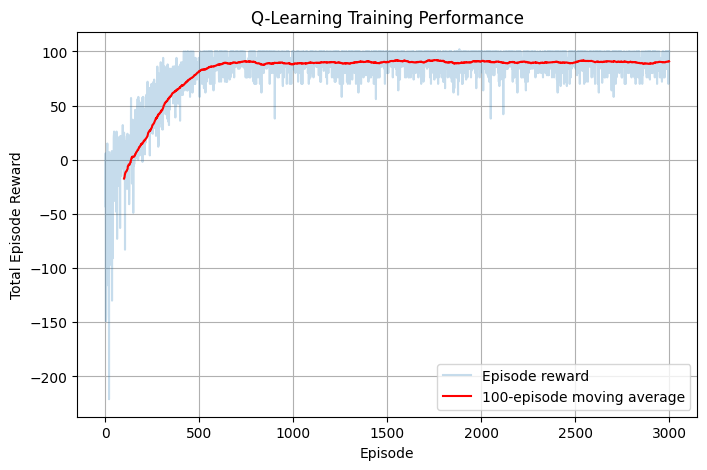

In [26]:
def moving_average(data, window=100):
    return np.convolve(data, np.ones(window) / window, mode="valid")

ma_rewards = moving_average(episode_rewards, window=100)

plt.figure(figsize=(8, 5))
plt.plot(episode_rewards, alpha=0.25, label="Episode reward")
plt.plot(range(99, len(episode_rewards)), ma_rewards, color="red", label="100-episode moving average")
plt.xlabel("Episode")
plt.ylabel("Total Episode Reward")
plt.title("Q-Learning Training Performance")
plt.legend()
plt.grid(True)
plt.show()

### Plot Epsilon Decay

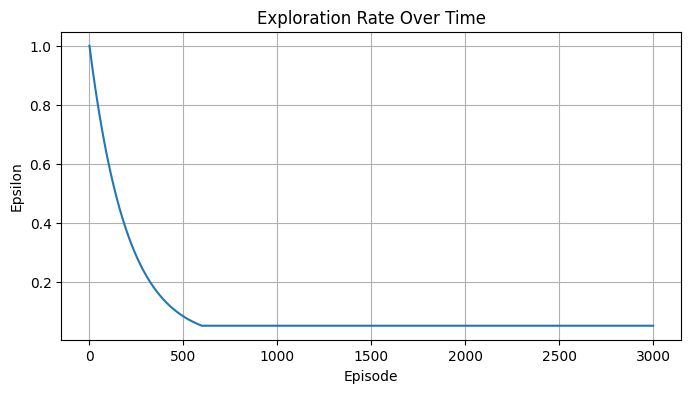

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(epsilons)
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Exploration Rate Over Time")
plt.grid(True)
plt.show()

### Display Final Q-Table as Heatmap

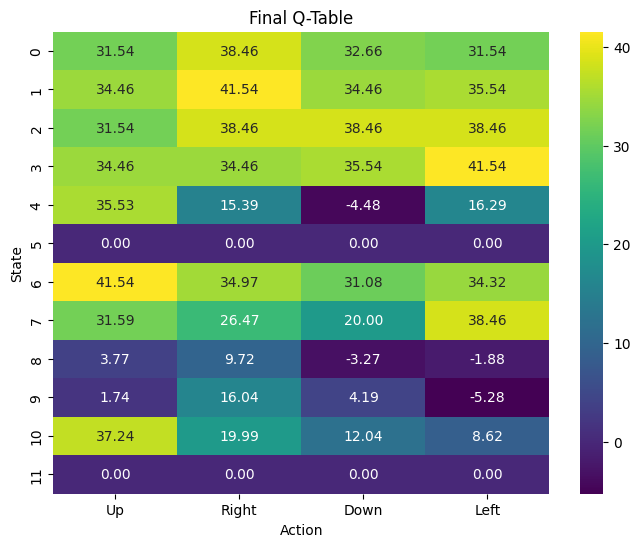

In [28]:
action_names = ["Up", "Right", "Down", "Left"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    Q,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=action_names,
    yticklabels=np.arange(env.observation_space.n)
)
plt.xlabel("Action")
plt.ylabel("State")
plt.title("Final Q-Table")
plt.show()

### Extract Final Policy

In [29]:
policy = np.argmax(Q, axis=1)
print("Policy action per state:")
print(policy)

Policy action per state:
[1 1 1 3 0 0 0 3 1 1 0 0]


### Policy Visualization

In [30]:
def visualize_policy(env, Q):
    action_symbols = {
        0: "↑",
        1: "→",
        2: "↓",
        3: "←"
    }

    policy = np.argmax(Q, axis=1)

    grid = np.empty((env.n_rows, env.n_cols), dtype=object)

    for state in range(env.n_states):
        pos = env.state_to_pos(state)

        if pos == env.start_pos:
            grid[pos] = "S/" + action_symbols[policy[state]]
        elif pos == env.goal_pos:
            grid[pos] = "G"
        elif pos == env.wall_pos:
            grid[pos] = "X"
        elif pos == env.treasure_pos:
            grid[pos] = "T/" + action_symbols[policy[state]]
        elif pos == env.bad_pos:
            grid[pos] = "B/" + action_symbols[policy[state]]
        else:
            grid[pos] = action_symbols[policy[state]]

    return grid

policy_grid = visualize_policy(env, Q)
print("Learned Policy:")
print(policy_grid)

Learned Policy:
[['S/→' '→' 'T/→' '←']
 ['↑' 'X' '↑' '←']
 ['B/→' '→' '↑' 'G']]


### Analysis
#### 1. What did the agent learn?
The agent learned a policy that moves from the start state to the goal while avoiding the wall and bad cell. In this environment, the best path usually goes along the top row:

```
S -> empty -> treasure -> empty -> down -> goal
```

This path has two advantages:
1. It reaches the goal in a small number of steps.
2. It collects the treasure reward along the way.

The agent also learns not to:
* Walk into the wall.
* Walk outside the grid.
* Move toward the bad/trap cell.
* Take unnecessary extra steps.

The final Q-table should show high values for actions that move toward the treasure and goal. Bad actions, such as moving into the wall or boundary, should have lower Q-values.

#### 2. How does the reward design affect convergence?
The reward design strongly shapes what the agent learns. In this environment:

* The -1 step penalty encourages shorter paths.
* The -5 wall/boundary penalty discourages invalid moves.
* The -10 trap penalty discourages visiting the bad cell.
* The +5 treasure reward encourages the agent to explore the top route.
* The +20 goal reward makes reaching the goal the main objective.

The agent learned what we expected - collect the treasure if it lies on or near the optimal route, avoid the trap, and reach the goal. If the treasure reward were much larger, the agent might take longer detours to collect it. If the step penalty were stronger, the agent would prefer shorter paths and might ignore a treasure that requires a detour. If the trap penalty were smaller, the agent might be less careful about avoiding it.

#### 3. Effect of changing $\gamma$ and $\epsilon$
The discount factor $\gamma$ determines how much the agent values future rewards. If $\gamma$ is high, the agent values delayed rewards. This helps it learn to move toward the goal even when the goal reward is several steps away. If $\gamma$ is low, the agent becomes short-sighted. It may care more about immediate rewards and penalties than the future goal reward. This can slow learning or produce a policy that does not reliably reach the goal.

The exploration rate $\epsilon$ controls how often the agent tries random actions. If $\epsilon$ starts high, the agent explores many paths early. This helps it discover the treasure and goal. If $\epsilon$ is too low from the beginning, the agent may exploit a poor early policy and fail to discover better routes. If $\epsilon$ decays too slowly, the agent keeps taking random actions even after learning a good policy. This can make episode rewards noisy. If $\epsilon$ decays too quickly, the agent may stop exploring before discovering the optimal path.

#### 4. Failure Modes
Possible failure modes include:
* Poor exploration - If the agent does not explore enough, it may never discover the goal or treasure. It may converge to a bad policy.
* Bad reward shaping - If the rewards are poorly designed, the agent may learn unintended behavior. For example, if invalid moves have no penalty, the agent may waste actions. If the treasure reward is too high and reusable, the agent may loop around the treasure instead of going to the goal.
* Too low discount factor - $\gamma$ is too small, the agent may fail to value the delayed goal reward and focus only on immediate rewards.
* Too few episodes - With insufficient training episodes, the Q-values may not converge, and the learned policy may be unstable.
* Large state space - Tabular Q-learning works well here because there are only 12 states and 4 actions. If the grid were much larger, Q-learning would require far more experience.

#### Making the Environment Harder or Easier
The environment would be harder if we:
* Enlarged the grid.
* Added more walls.
* Added stochastic transitions, such as slipping to a random adjacent cell.
* Reduced the goal reward.
* Increased the trap penalty.
* Placed the treasure in a risky location.
* Added multiple traps.
* Used partial observability.
* Required collecting a key before reaching the goal.

The environment would become easier if we:
* Removed the wall.
* Removed the bad cell.
* Increased the goal reward.
* Reduced the step penalty.
* Started the agent closer to the goal.
* Used a smaller grid.
* Initialized Q-values optimistically.
* Reduced randomness in transitions.

# Q3 — Explore $\beta$-VAE Trade-offs with KL Diagnostics on MNIST

## 40 points total

### Objective

Variational Autoencoders (VAEs) introduce a probabilistic latent space for generative modeling. Compared to a Vanilla Autoencoder, which only learns to reconstruct inputs, VAEs and $\beta$-VAEs learn a probabilistic latent space that supports sampling and generation. A $\beta$-VAE (beta-Variational Autoencoder) extends the standard VAE by introducing a weighting factor $\beta$ (hyperparameter) on the Kullback–Leibler (KL)-divergence term in the ELBO objective to balance reconstruction quality and latent regularization. 

$\mathcal{L}_{\beta\text{-VAE}} = \mathbb{E}_{q_\phi(z|x)}[-\log p_\theta(x|z)] + \beta \cdot \text{KL}(q_\phi(z|x) \parallel p(z))$

Increasing $\beta$ encourages more disentangled and interpretable latent features but can reduce reconstruction accuracy, revealing a key trade-off between structure and fidelity.

You will train a $\beta$-VAE with a convolutional encoder/decoder on MNIST, test some $\beta$ values, and compare their effects through plots and visuals.

### [5 points] Part A – Prepare Data

__Goal:__ Prepare the MNIST dataset for input to a convolutional $\beta$-VAE. Ensure all images are correctly normalized and shaped for a ConvNet-based model.

1. Use the MNIST handwritten digit dataset via ```torchvision.datasets.MNIST```.
2. Apply the following transformation via ```transforms.ToTensor()```
   - Normalize pixel values to the $[0,1]$ range. 
   - Reshape to (1, 28, 28) and treat as a single-channel grayscale image.
3. Verify image shape. 
4. (Optional) Use a subset of 10,000–20,000 samples from the training set to reduce training time.


### [10 points] Part B – Set up a $\beta$-VAE with a Convolutional Architecture

__Goal:__ Implement a convolutional $\beta$-VAE architecture suitable for MNIST. Understand how the encoder, decoder, and loss function interact in variational generative modeling.

Use the following convolutional architecture:
- **Encoder**: Fully connected layers that map input 28×28 pixels to a latent Gaussian distribution  
Conv2d $\rightarrow$ ReLU $\rightarrow$ Conv2d $\rightarrow$ ReLU $\rightarrow$ Flatten $\rightarrow$ FC layers to produce $\mu$ (mean of latent distribution) and $\log{\sigma^2}$ (log-variance of latent distribution)
- **Decoder**: Maps $z$ back to 28×28 pixels using a sigmoid output layer  
FC $\rightarrow$ Unflatten $\rightarrow$ ConvTranspose2d $\rightarrow$ ReLU $\rightarrow$ ConvTranspose2d $\rightarrow$ Sigmoid, that output should be a reconstructed image of (1, 28, 28)
- **Latent Prior**:  Use a smaller latent dimension (e.g., 2) if you wish to visualize the latent space; otherwise, use 10.
- **Loss**: Use binary cross-entropy (BCE) reconstruction loss and KL divergence  

$$
\mathcal{L}_{\beta\text{-VAE}} = \text{BCE}(x, \hat{x}) + \beta \cdot \text{KL}(q(z|x) \parallel \mathcal{N}(0, I)) \\
, \text{where  } z = \mu + \sigma \cdot \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)
$$



### [15 points] Part C – Train β-VAE and Track Loss


__Goal:__ Train the model using different $\beta$ values and observe their effect on the balance between reconstruction and KL divergence.

- Choose at least two $\beta$ values greater than 0 (e.g., $\beta \in \{0.5, 1, 4\}$) or try linearly increasing values.
- Train for 10–15 epochs per setting.
- Use ```latent_dim = 10```
- Use Adam Optimizer (learning rate $lr = 1e‑3$, batch size = 128).
- For each epoch, log and print the following:
  - Total loss
  - Reconstruction loss (BCE)
  - KL divergence
- (Optional) Save trained model weights and per-epoch metrics for visualization in Part D.


### [10 points] Part D – Visualize and Interpret

__Goal:__ Assess how $\beta$ influences model performance in terms of reconstruction fidelity and sample quality.

1. For each trained model (for each $\beta$), do the following: 
   - Pick 5 test-set images and show original vs. reconstructed side-by-side.
   - Sample 5 random latent vectors from \( \mathcal{N}(0, I) \), decode them, and show the generated outputs.
2. Reflect on your results - the observed impact of $\beta$ on learning dynamics, reconstruction, and generative quality.
   - Which $\beta$ gives better reconstructions? Which gives more diverse or sharper samples?
   - How does increasing $\beta$ affect the KL divergence and reconstruction error?
   - Do you observe KL → 0 (posterior collapse)?
   - What are the risks of using too small or too large a $\beta$?

## Part A Solution

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 472kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.36MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.71MB/s]
/Users/andrewjowe/PycharmProjects/EN.705.623.81.SU26/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch image shape: torch.Size([128, 1, 28, 28])
Batch label shape: torch.Size([128])
Pixel min: 0.0
Pixel max: 1.0


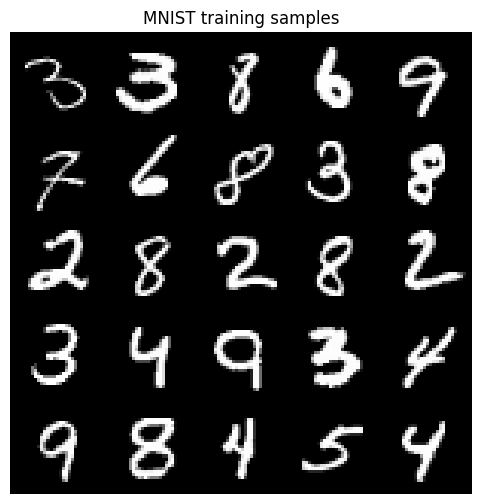

In [31]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)
np.random.seed(0)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

transform = transforms.ToTensor()

train_dataset_full = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

use_subset = True
subset_size = 20000

if use_subset:
    indices = np.random.choice(len(train_dataset_full), subset_size, replace=False)
    train_dataset = Subset(train_dataset_full, indices)
else:
    train_dataset = train_dataset_full

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

x_batch, y_batch = next(iter(train_loader))

print("Batch image shape:", x_batch.shape)
print("Batch label shape:", y_batch.shape)
print("Pixel min:", x_batch.min().item())
print("Pixel max:", x_batch.max().item())

plt.figure(figsize=(6, 6))
grid = make_grid(x_batch[:25], nrow=5, padding=2)
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("MNIST training samples")
plt.axis("off")
plt.show()

## Part B Solution

We implement a convolutional β-VAE. The architecture is as follows.

Encoder:
```
Input: 1 x 28 x 28
Conv2d: 1 -> 32, kernel=4, stride=2, padding=1     gives 32 x 14 x 14
ReLU
Conv2d: 32 -> 64, kernel=4, stride=2, padding=1    gives 64 x 7 x 7
ReLU
Flatten
FC to hidden
FC to mu
FC to logvar
```

Decoder:
```
Latent z
FC
FC to 64 x 7 x 7
Unflatten
ConvTranspose2d: 64 -> 32, kernel=4, stride=2, padding=1   gives 32 x 14 x 14
ReLU
ConvTranspose2d: 32 -> 1, kernel=4, stride=2, padding=1    gives 1 x 28 x 28
Sigmoid
```

In [32]:
class ConvBetaVAE(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU()
        )

        self.flatten_dim = 64 * 7 * 7

        self.encoder_fc = nn.Sequential(
            nn.Linear(self.flatten_dim, 256),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, self.flatten_dim),
            nn.ReLU()
        )

        self.decoder_deconv = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels=64,
                out_channels=32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                in_channels=32,
                out_channels=1,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(x.size(0), -1)
        h = self.encoder_fc(h)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        z = mu + sigma * epsilon
        where epsilon ~ N(0, I)
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + std * eps

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(z.size(0), 64, 7, 7)
        x_hat = self.decoder_deconv(h)

        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)

        return x_hat, mu, logvar

### β-VAE Loss Function
The β-VAE objective is:
$$\mathcal{L}_{\beta\text{-VAE}}
=
\text{BCE}(x,\hat{x})
+
\beta \cdot
\text{KL}(q_\phi(z|x)\parallel p(z))$$
For a diagonal Gaussian posterior:
$$q_\phi(z|x)=\mathcal{N}(\mu, \sigma^2 I)$$
And standard normal prior:
$$p(z)=\mathcal{N}(0,I)$$
The KL term is:
$$\text{KL}
=
-\frac{1}{2}
\sum_j
\left(
1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2
\right)$$


In [33]:
def beta_vae_loss(x_hat, x, mu, logvar, beta=1.0):
    # Sum over pixels and batch.
    # This is common for VAE training.
    bce = F.binary_cross_entropy(
        x_hat,
        x,
        reduction="sum"
    )

    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = bce + beta * kl

    return total_loss, bce, kl

## Part C — Train $\beta$-VAE and Track Loss

In [35]:
def train_one_epoch(model, train_loader, optimizer, beta, device):
    model.train()

    total_loss_sum = 0.0
    bce_sum = 0.0
    kl_sum = 0.0
    num_samples = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mu, logvar = model(x)
        loss, bce, kl = beta_vae_loss(x_hat, x, mu, logvar, beta=beta)

        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        num_samples += batch_size

        total_loss_sum += loss.item()
        bce_sum += bce.item()
        kl_sum += kl.item()

    avg_total_loss = total_loss_sum / num_samples
    avg_bce = bce_sum / num_samples
    avg_kl = kl_sum / num_samples

    return avg_total_loss, avg_bce, avg_kl

### Evaluation Function

In [36]:
@torch.no_grad()
def evaluate(model, data_loader, beta, device):
    model.eval()

    total_loss_sum = 0.0
    bce_sum = 0.0
    kl_sum = 0.0
    num_samples = 0

    for x, _ in data_loader:
        x = x.to(device)

        x_hat, mu, logvar = model(x)
        loss, bce, kl = beta_vae_loss(x_hat, x, mu, logvar, beta=beta)

        batch_size = x.size(0)
        num_samples += batch_size

        total_loss_sum += loss.item()
        bce_sum += bce.item()
        kl_sum += kl.item()

    avg_total_loss = total_loss_sum / num_samples
    avg_bce = bce_sum / num_samples
    avg_kl = kl_sum / num_samples

    return avg_total_loss, avg_bce, avg_kl

### Training Loop for Several $\beta$ Values

In [37]:
latent_dim = 10
epochs = 15
learning_rate = 1e-3

beta_values = [0.5, 1.0, 4.0]

trained_models = {}
history = {}

for beta in beta_values:
    print("=" * 60)
    print(f"Training β-VAE with beta = {beta}")
    print("=" * 60)

    model = ConvBetaVAE(latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history[beta] = {
        "train_total": [],
        "train_bce": [],
        "train_kl": [],
        "test_total": [],
        "test_bce": [],
        "test_kl": []
    }

    for epoch in range(1, epochs + 1):
        train_total, train_bce, train_kl = train_one_epoch(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            beta=beta,
            device=device
        )

        test_total, test_bce, test_kl = evaluate(
            model=model,
            data_loader=test_loader,
            beta=beta,
            device=device
        )

        history[beta]["train_total"].append(train_total)
        history[beta]["train_bce"].append(train_bce)
        history[beta]["train_kl"].append(train_kl)
        history[beta]["test_total"].append(test_total)
        history[beta]["test_bce"].append(test_bce)
        history[beta]["test_kl"].append(test_kl)

        print(
            f"Epoch [{epoch:02d}/{epochs}] "
            f"Train Loss: {train_total:.2f} | "
            f"Train BCE: {train_bce:.2f} | "
            f"Train KL: {train_kl:.2f} || "
            f"Test Loss: {test_total:.2f} | "
            f"Test BCE: {test_bce:.2f} | "
            f"Test KL: {test_kl:.2f}"
        )

    trained_models[beta] = copy.deepcopy(model).cpu()

os.makedirs("vae_checkpoints", exist_ok=True)

for beta, model in trained_models.items():
    torch.save(model.state_dict(), f"vae_checkpoints/beta_vae_beta_{beta}.pt")

np.save("vae_checkpoints/history.npy", history, allow_pickle=True)

Training β-VAE with beta = 0.5
Epoch [01/15] Train Loss: 215.29 | Train BCE: 212.27 | Train KL: 6.03 || Test Loss: 172.43 | Test BCE: 167.63 | Test KL: 9.60
Epoch [02/15] Train Loss: 143.79 | Train BCE: 136.03 | Train KL: 15.53 || Test Loss: 122.68 | Test BCE: 112.96 | Test KL: 19.45
Epoch [03/15] Train Loss: 114.04 | Train BCE: 103.76 | Train KL: 20.54 || Test Loss: 109.42 | Test BCE: 98.70 | Test KL: 21.44
Epoch [04/15] Train Loss: 106.10 | Train BCE: 95.33 | Train KL: 21.55 || Test Loss: 103.66 | Test BCE: 92.60 | Test KL: 22.13
Epoch [05/15] Train Loss: 102.67 | Train BCE: 91.68 | Train KL: 21.97 || Test Loss: 102.39 | Test BCE: 91.40 | Test KL: 21.98
Epoch [06/15] Train Loss: 100.28 | Train BCE: 89.13 | Train KL: 22.31 || Test Loss: 99.82 | Test BCE: 88.32 | Test KL: 22.99
Epoch [07/15] Train Loss: 98.81 | Train BCE: 87.56 | Train KL: 22.50 || Test Loss: 98.54 | Test BCE: 87.31 | Test KL: 22.45
Epoch [08/15] Train Loss: 97.54 | Train BCE: 86.19 | Train KL: 22.69 || Test Loss: 97.3

### Plot Loss Curves

In [38]:
def plot_metric(history, metric_name, title, ylabel):
    plt.figure(figsize=(8, 5))

    for beta in history:
        plt.plot(
            history[beta][metric_name],
            marker="o",
            label=f"beta={beta}"
        )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

### Training Total Loss

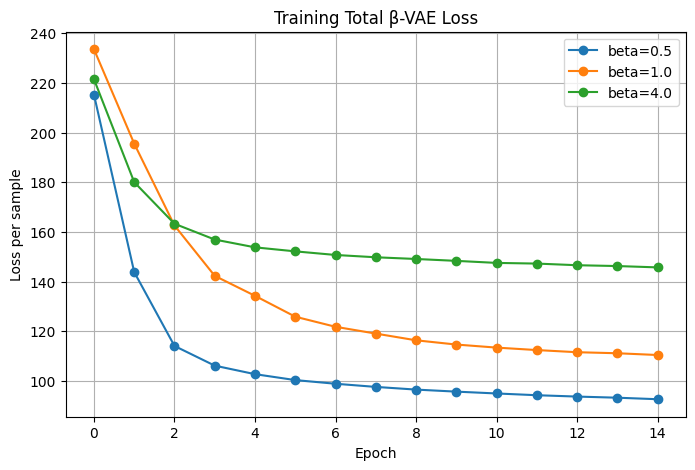

In [39]:
plot_metric(
    history,
    "train_total",
    "Training Total β-VAE Loss",
    "Loss per sample"
)

### Training Reconstruction BCE

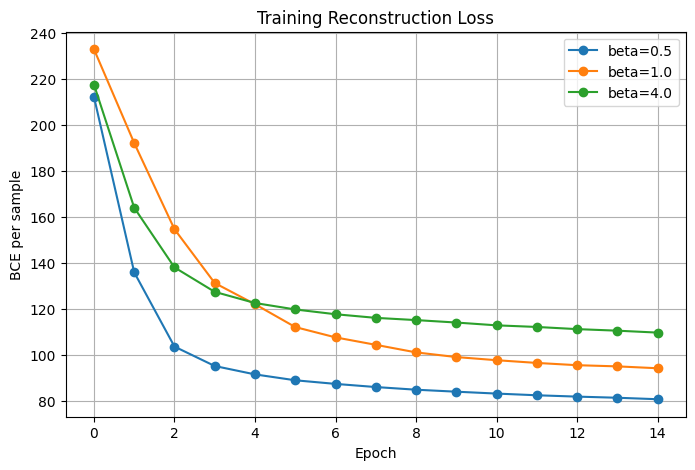

In [40]:
plot_metric(
    history,
    "train_bce",
    "Training Reconstruction Loss",
    "BCE per sample"
)

### Training KL Divergence

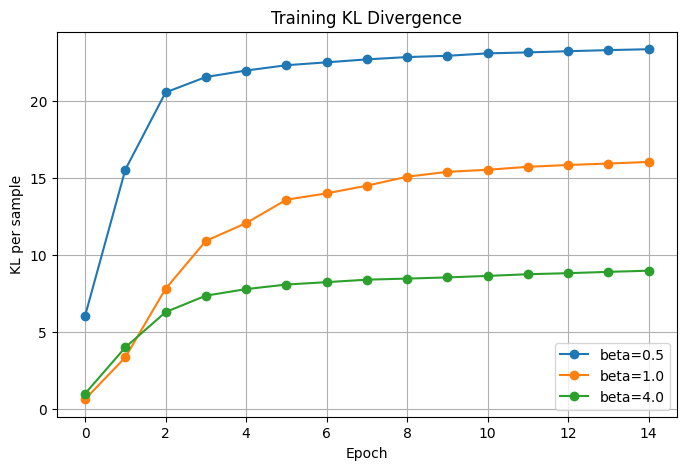

In [41]:
plot_metric(
    history,
    "train_kl",
    "Training KL Divergence",
    "KL per sample"
)

### Test Metrics

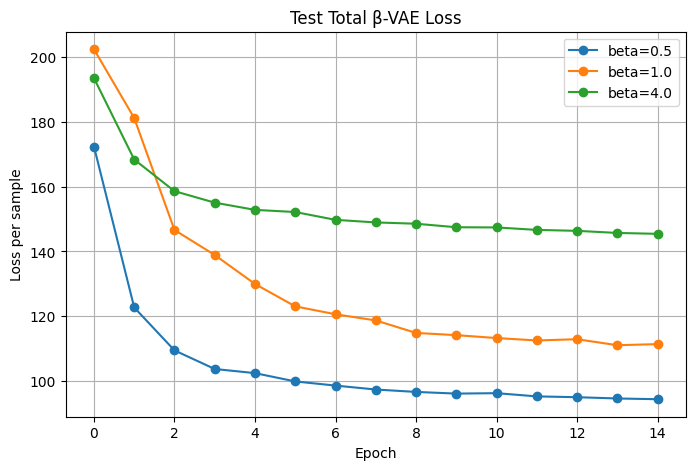

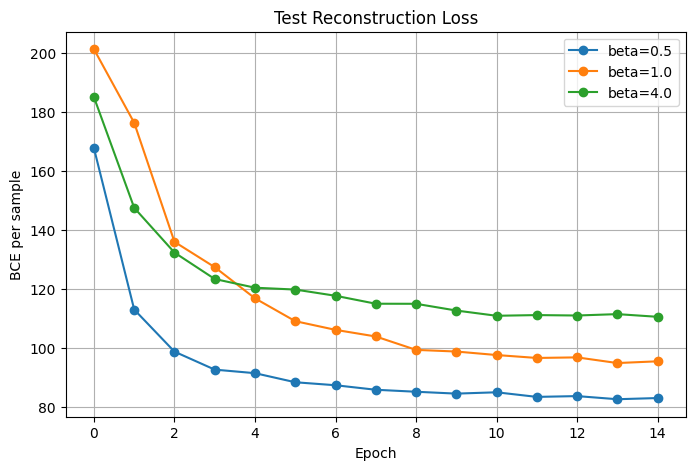

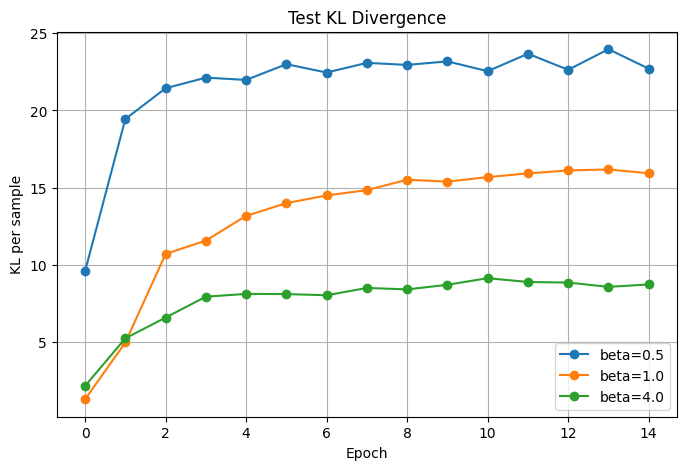

In [42]:
plot_metric(
    history,
    "test_total",
    "Test Total β-VAE Loss",
    "Loss per sample"
)

plot_metric(
    history,
    "test_bce",
    "Test Reconstruction Loss",
    "BCE per sample"
)

plot_metric(
    history,
    "test_kl",
    "Test KL Divergence",
    "KL per sample"
)

## Part D — Visualize and Interpret
### Reconstruction Visualization

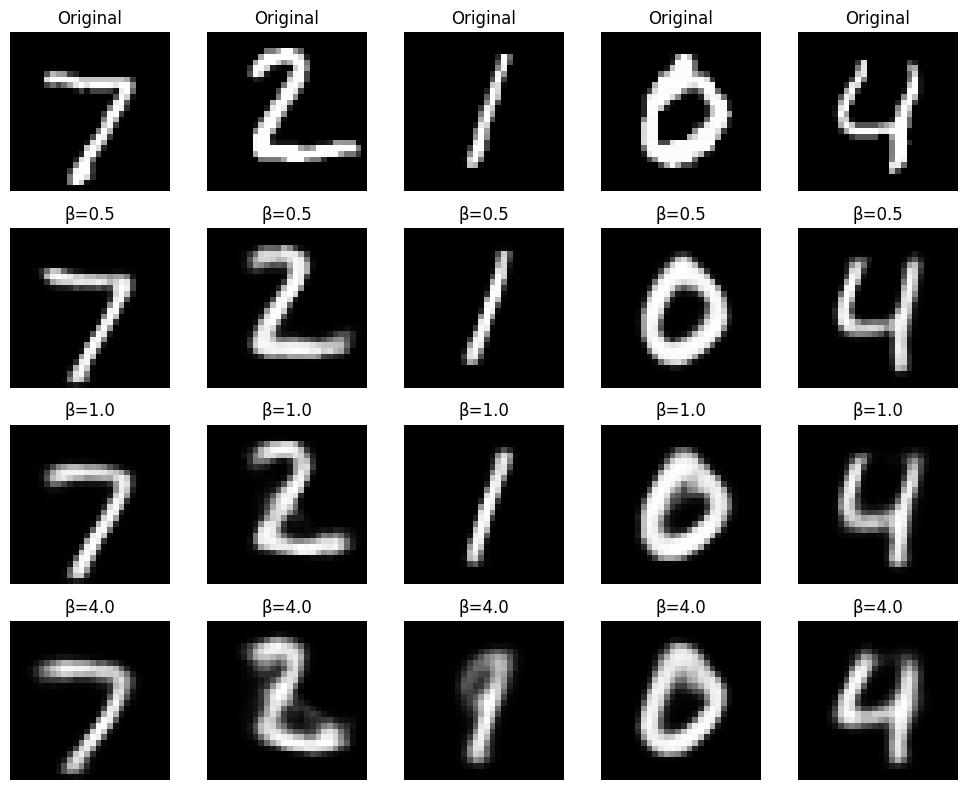

In [43]:
@torch.no_grad()
def show_reconstructions(models, test_loader, device, n=5):
    x, y = next(iter(test_loader))
    x = x[:n].to(device)

    num_betas = len(models)

    plt.figure(figsize=(2 * n, 2 * (num_betas + 1)))

    # Original row
    for i in range(n):
        plt.subplot(num_betas + 1, n, i + 1)
        plt.imshow(x[i, 0].cpu(), cmap="gray")
        plt.title("Original")
        plt.axis("off")

    # Reconstruction rows
    row = 1
    for beta, model in models.items():
        model = model.to(device)
        model.eval()

        x_hat, _, _ = model(x)

        for i in range(n):
            plt.subplot(num_betas + 1, n, row * n + i + 1)
            plt.imshow(x_hat[i, 0].cpu(), cmap="gray")
            plt.title(f"β={beta}")
            plt.axis("off")

        model.cpu()
        row += 1

    plt.tight_layout()
    plt.show()

show_reconstructions(trained_models, test_loader, device, n=5)

### Random Sampling from the Prior
Sample random latent vectors:
$$z \sim \mathcal{N}(0,I)$$
Then decode them.

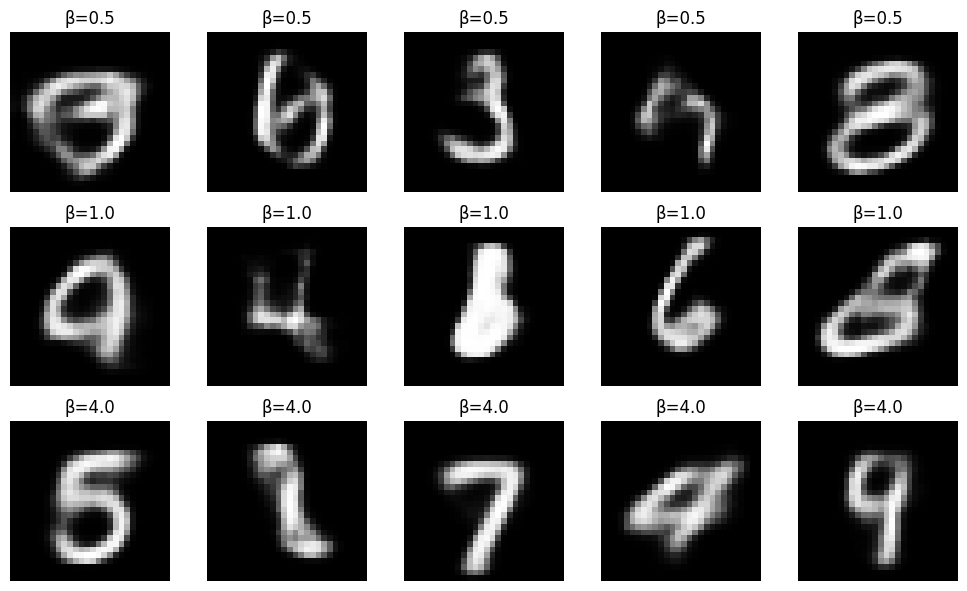

In [44]:
@torch.no_grad()
def show_random_samples(models, latent_dim, device, n=5):
    num_betas = len(models)

    plt.figure(figsize=(2 * n, 2 * num_betas))

    for row, (beta, model) in enumerate(models.items()):
        model = model.to(device)
        model.eval()

        z = torch.randn(n, latent_dim).to(device)
        samples = model.decode(z)

        for i in range(n):
            plt.subplot(num_betas, n, row * n + i + 1)
            plt.imshow(samples[i, 0].cpu(), cmap="gray")
            plt.title(f"β={beta}")
            plt.axis("off")

        model.cpu()

    plt.tight_layout()
    plt.show()

show_random_samples(trained_models, latent_dim, device, n=5)

### Visualization

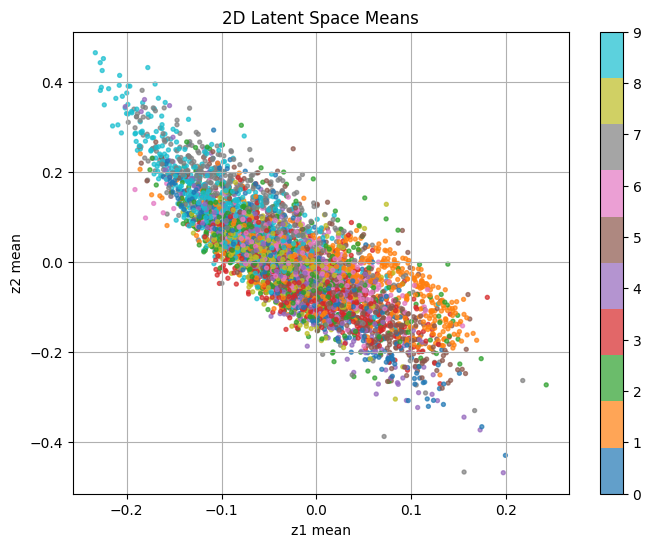

In [45]:
@torch.no_grad()
def plot_latent_space_2d(model, data_loader, device, max_points=5000):
    model = model.to(device)
    model.eval()

    mus = []
    labels = []

    count = 0

    for x, y in data_loader:
        x = x.to(device)

        mu, logvar = model.encode(x)

        mus.append(mu.cpu())
        labels.append(y)

        count += x.size(0)

        if count >= max_points:
            break

    mus = torch.cat(mus, dim=0)[:max_points]
    labels = torch.cat(labels, dim=0)[:max_points]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        mus[:, 0],
        mus[:, 1],
        c=labels,
        cmap="tab10",
        s=8,
        alpha=0.7
    )
    plt.colorbar(scatter, ticks=range(10))
    plt.xlabel("z1 mean")
    plt.ylabel("z2 mean")
    plt.title("2D Latent Space Means")
    plt.grid(True)
    plt.show()

    model.cpu()

plot_latent_space_2d(trained_models[1.0], test_loader, device)

## Interpretation
### 1. Which $\beta$ gives better reconstructions?
Usually, smaller $\beta$ values give better reconstructions because the model is allowed to use the latent space more freely. The KL penalty is weaker, so the encoder can store more information about each input image in $z$. In the reconstruction plots, $\beta = 0.5$ or $\beta = 1.0$ should usually preserve digit identity and stroke shape better than $\beta = 4.0$. With larger $\beta$, reconstructions may become blurrier, more averaged, or less faithful to the exact input digit.
### 2. Which $\beta$ gives more diverse or sharper generated samples?
There is a trade-off.

A smaller $\beta$ can give good reconstructions but may produce a less regular latent space. That means random samples from $z \in \mathcal{N}(0,I)$ may not always decode into clean digits, because the aggregated posterior may not match the standard normal prior very well.

A larger $\beta$ forces the latent posterior closer to $\mathcal{N}(0,I)$. This can make random sampling more reliable because the decoder has learned to decode latent vectors from a space closer to the prior. However, if β is too large, the model may ignore details and produce blurry or generic samples.

### 3. How does increasing β affect KL divergence and reconstruction error?
Increasing β places more weight on the KL term:
$$\text{Loss} = \text{BCE} + \beta \cdot \text{KL}$$

As β increases, the model is more strongly penalized when $q_\phi(z|x)$ moves far from:
$$p(z)=\mathcal{N}(0,I)$$

Therefore, increasing $\beta$ usually causes KL divergence to fall and Reconstruction BCE to rise. The model sacrifices reconstruction accuracy to keep the latent distribution closer to the prior. This is exactly the $\beta$-VAE trade-off where:

* lower $\beta$ means more information in latent code, better reconstructions
* higher $\beta$ means more regularized latent space, potentially more disentangled features, worse reconstructions


### 4. Do we observe KL → 0, or posterior collapse?
Posterior collapse happens when:
$$\text{KL}(q_\phi(z|x)\parallel p(z)) \approx 0$$

This means that $q_\phi(z|x) \approx p(z)$ for all inputs. In that case, the latent variable z carries little or no information about the input x. If KL goes near zero while reconstruction remains poor, the decoder is mostly ignoring the latent code. This is posterior collapse.

A warning sign is when:
* KL per sample is approximately 0
* BCE high
* Reconstructions look similar or washed out
* Random samples lack digit structure

### 5. Risks of using too small or too large a $\beta$
#### $\beta$ too small
If $\beta$ is too small, the model behaves more like a regular autoencoder. Possible issues include:
* Excellent reconstructions.
* Weak latent regularization.
* Posterior distribution may be far from standard normal.
* Random samples from $N(0,I)$ may decode poorly.
* Latent space may have holes or discontinuities.
* Poorer generative behavior.

In these cases, the model may memorize training examples more easily.

#### $\beta$ too large
If $\beta$ is too large, then the KL penalty dominates. Possible issues include:
* Latent representations carry too little information.
* KL can collapse toward zero.
* Reconstructions become blurry or inaccurate.
* Generated digits may become generic.
* Decoder may ignore z.
* Training may underfit.